1. Create API call to extract gov data
Link to Austender Website: https://www.tenders.gov.au/Reports/CnPublishedForm


Website to read Json Format: https://jsonformatter.curiousconcept.com/

If json contains "next" under links. then this means the returned data from the API is not compelte. Another call needs to be made to the url in the next section to return the additional data, until there is no next section. Use this as a criteria to loop through and apply the function. 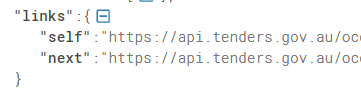

API Reference Data: https://github.com/austender/austender-ocds-api/tree/master

In [1]:
def read_austender_data(start,end):
    import requests
    import json

    start_date = start
    end_date = end

    url = f'https://api.tenders.gov.au/ocds/findByDates/contractPublished/{start_date}/{end_date}'

    response = requests.get(url)
    data = response.json()
    return data



In [2]:
def read_more_austender_data(url):
    import requests
    import json

    response = requests.get(url)
    data = response.json()
    return data

In [3]:
import pandas as pd

def pandas_data_frame(data_list):
    '''Create a flat file for the dataframe'''


    
    rows = []

    for page in data_list:
        for release in page.get('releases',[]):

            ocid = release.get('ocid')
            tender = release.get('tender',{})

            procurement_method = tender.get('procurementMethod')

            # Parties (supplier + procuring entity)
            parties = release.get('parties',[])

            # Awards (supplier info lives here too)
            awards = release.get('awards',[])

            # Contracts (value, UNSPSC, dates)
            contracts = release.get('contracts',[])

            for contract in contracts:
                contract_id = contract.get('id')
                contract_title = contract.get('title')
                contract_description = contract.get('description')

                #Contract Amounts
                value = contract.get('value',{})
                amount = value.get('amount')
                currency = value.get('currency')

                #Periods
                period = contract.get('period',{})
                start_date = period.get('startDate')
                end_date = period.get('endDate')

                #UNSPSC classification
                unspsc = None
                items = contract.get('items',[])
                for item in items:
                    classification = item.get('classification',{})
                    unspsc = classification.get('id')
                    break
                 

                #government agencies default
                agency_name = None
            

                for p in parties:
                    roles = p.get('roles',[])
                    if 'procuringEntity' in roles:
                        agency_name = p.get('name')
                        break
                
                #Suppliers
                supplier_name = None
                supplier_abn = None
                locality = None
                region = None
                postal = None
                country = None

                if awards:
                    suppliers = awards[0].get('suppliers',[])
                    if suppliers:
                        supplier_name = suppliers[0].get('name')

                        for p in parties:
                            if p.get('name') == supplier_name:
                                address = p.get('address',{})
                                locality = address.get('locality')
                                region = address.get('region')
                                postal = address.get('postalCode')
                                country = address.get('countryName')
                                break


                rows.append({
                    'ocid':ocid,
                    'contract_id':contract_id,
                    'contract_title':contract_title,
                    'contract_description':contract_description,
                    'supplier_name':supplier_name,
                    'unspsc':unspsc,
                    'amount':amount,
                    'start_date':start_date,
                    'end_date':end_date,
                    'locality':locality,
                    'region':region,
                    'postal':postal,
                    'country':country,
                    'procurement_method':procurement_method,
                    'agency_name':agency_name
                    })


    df = pd.DataFrame(rows)
    df['amount'] = pd.to_numeric(df['amount'],errors='coerce')


    return df

In [4]:
#If there are only 1 link then 'links' don't appear in the json

pages = []

begin_period = '2026-06-01T00:00:00Z'
end_period = '2026-07-08T23:59:59Z'


current = read_austender_data(begin_period,end_period)

while True:
    pages.append(current)

    links = current.get('links',{})
    next_url = links.get('next')

    if not next_url:
        break

    current = read_more_austender_data(next_url)


In [5]:
austender_df = pandas_data_frame(pages)

In [6]:
austender_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8552 entries, 0 to 8551
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ocid                  8552 non-null   object 
 1   contract_id           8552 non-null   object 
 2   contract_title        8487 non-null   object 
 3   contract_description  8552 non-null   object 
 4   supplier_name         8552 non-null   object 
 5   unspsc                8552 non-null   object 
 6   amount                8552 non-null   float64
 7   start_date            8552 non-null   object 
 8   end_date              8552 non-null   object 
 9   locality              8552 non-null   object 
 10  region                8552 non-null   object 
 11  postal                8549 non-null   object 
 12  country               8552 non-null   object 
 13  procurement_method    8552 non-null   object 
 14  agency_name           8552 non-null   object 
dtypes: float64(1), object

In [7]:

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
sns.set_theme(style='whitegrid')



In [8]:
austender_df

,ocid,contract_id,contract_title,contract_description,supplier_name,unspsc,amount,start_date,end_date,locality,region,postal,country,procurement_method,agency_name
0,prod-c82aee8b1ab649e591d56d3236410e99,CN4259620,3000354903,Repair of Electronic Component Assemblies,THALES AUSTRALIA,32100000,50466.80,2026-07-06T14:00:00Z,2027-06-06T14:00:00Z,Sydney Olympic Park,NSW,2127,AUSTRALIA,limited,Department of Defence
1,prod-f47848b88ddd407fbf0bcdb5666de524,CN4259619,3000381171,Batteries,ECASTLE PTY LTD,26110000,300080.00,2025-12-18T13:00:00Z,2026-06-29T14:00:00Z,FYSHWICK,ACT,2609,AUSTRALIA,limited,Department of Defence
2,prod-1d52efae22d443d581d85dadef9e72d6,CN4259617,3000470274,Test Equipment,ROSEBANK ENGINEERING PTY LTD,46190000,120890.00,2026-06-21T14:00:00Z,2026-11-29T13:00:00Z,BAYSWATER,VIC,3153,AUSTRALIA,limited,Department of Defence
3,prod-ac9612666fac43bfb9938459c6df1f20,CN4259618,3000470250,Test Equipment,ROSEBANK ENGINEERING PTY LTD,46190000,96800.00,2026-06-16T14:00:00Z,2026-11-29T13:00:00Z,BAYSWATER,VIC,3153,AUSTRALIA,limited,Department of Defence
4,prod-2583700b61094ff3b1fc04941271a0ad,CN4259616,3000618386,Pump Repair,WATMAR ENGINEERING PTY LTD,40150000,20016.21,2026-07-05T14:00:00Z,2026-08-27T14:00:00Z,NAVAL BASE,WA,6165,AUSTRALIA,limited,Department of Defence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8547,prod-7e5791f9ca674e01b6e239877eae79a9,CN4245709,AC3051,Analyst IT Service Desk (LH-06238-MTP),MTP Services Pty Ltd,80111600,80639.20,2026-06-07T14:00:00Z,2026-12-06T13:00:00Z,Fyshwick,ACT,2609,AUSTRALIA,open,Australian Transaction Reports and Analysis Ce...
8548,prod-ee43b1b92c884f5a9d61ee50799aaa63,CN4245706,SCO002923-0,Labour Hire,Hays Personnel Services (Aust) PL,80111600,178718.00,2026-05-31T14:00:00Z,2027-05-30T14:00:00Z,Sydney,NSW,2001,AUSTRALIA,open,Australian Financial Security Authority
8549,prod-1c749af511044586a7c73eb79289985c,CN4245707,SCO002888-0,Labour Hire,Hays Personnel Services (Aust) PL,80111600,178718.00,2026-05-31T14:00:00Z,2027-05-30T14:00:00Z,Sydney,NSW,2001,AUSTRALIA,open,Australian Financial Security Authority
8550,prod-2e253c4485f44c42bd4d3a90b16a9c2c,CN4245704,SCO002914-0,Introduction and Placement Services,TALENT INTERNATIONAL HOLDINGS PTY LTD,80111600,50000.00,2026-05-31T14:00:00Z,2027-03-30T13:00:00Z,Deakin,ACT,2600,AUSTRALIA,open,Australian Financial Security Authority


In [22]:
#Top 5 By Average Amount Spend per trender by Agency during the Period. 
#Also listing Total Amount

top5AgencySpend = austender_df.groupby(
    'agency_name',as_index=False
    ).agg(
        avg_amount = ('amount','mean'),
        total_amount = ('amount','sum'),
        num_of_contracts = ('contract_id','count')        
        ).sort_values('avg_amount',ascending=False).head(5)

#top5AgencySpend['avg_amount'] = top5AgencySpend['avg_amount'].apply(lambda x : f'{x:,.0f}')
#top5AgencySpend['total_amount'] = top5AgencySpend['total_amount'].apply(lambda x : f'{x:,.0f}')
top5AgencySpend

,agency_name,avg_amount,total_amount,num_of_contracts
117,Tourism Australia,3.341251e+07,2.004751e+08,6
39,CSIRO,1.463598e+07,3.951716e+08,27
88,National Gallery of Australia,9.441343e+06,8.497209e+07,9
78,Independent Parliamentary Expenses Authority,7.854208e+06,7.854208e+06,1
53,Department of Foreign Affairs and Trade - Aust...,5.736569e+06,1.606239e+08,28


C:\Users\shaun\AppData\Local\Temp\ipykernel_26744\2430429179.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45,ha='right')


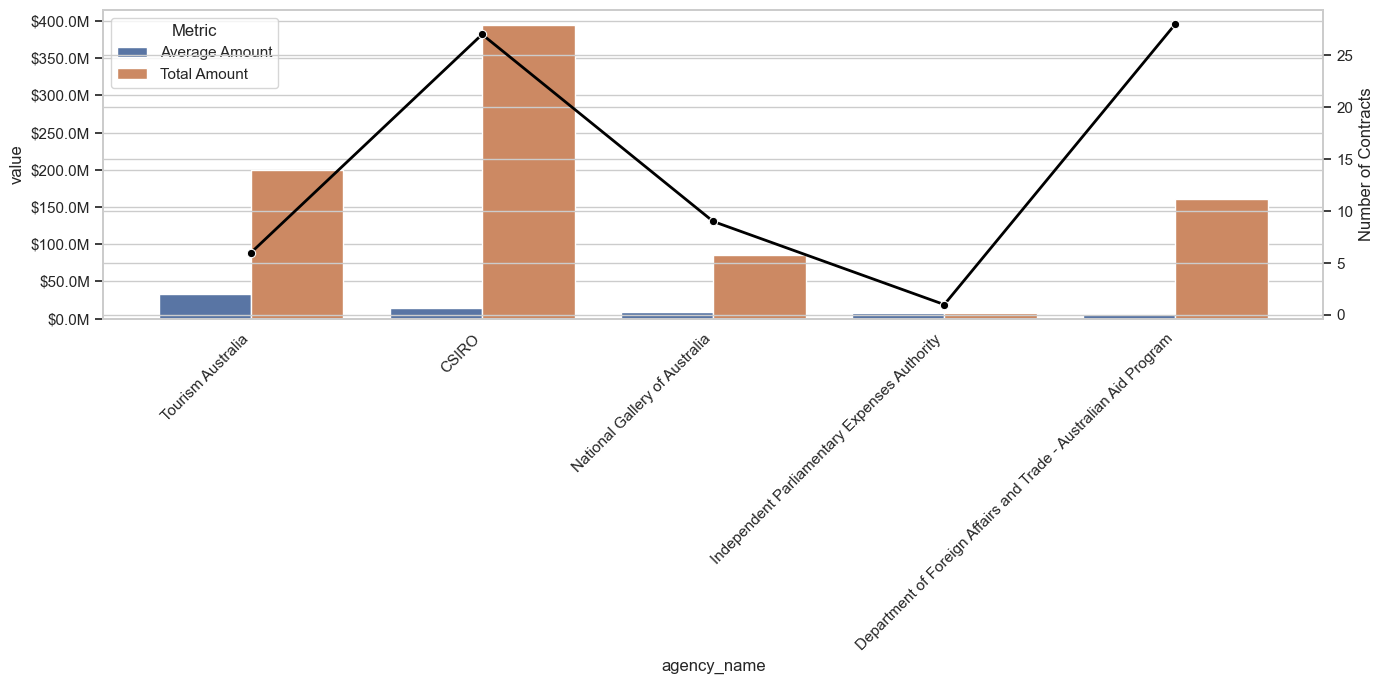

In [39]:
plot_top5AgencySpend = top5AgencySpend.melt(
    id_vars='agency_name',
    value_vars = ['avg_amount','total_amount','num_of_contracts'],
    var_name='metric',
    value_name = 'value'
)


bars_df = plot_top5AgencySpend[
    plot_top5AgencySpend['metric'].isin(['avg_amount','total_amount'])
    ]

line_df = plot_top5AgencySpend[
    plot_top5AgencySpend['metric']==('num_of_contracts')
    ]

fig, ax1 = plt.subplots(figsize=(14,7))

sns.barplot(
    data=bars_df,
    x='agency_name',
    y='value',
    hue='metric',
    ax=ax1
)

ax1.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_:f'${x/1_000_000:.1f}M')
)

ax2= ax1.twinx()



sns.lineplot(
    data=line_df,
    x='agency_name',
    y='value',
    marker='o',
    color='black',
    linewidth=2,
    ax = ax2,
    legend=False
)

ax2.set_ylabel('Number of Contracts')

handles,labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles,
    ['Average Amount','Total Amount'],
    title='Metric',
    loc='upper left'
    )


ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45,ha='right')


plt.tight_layout()
plt.show()

In [11]:
top5_supplier = austender_df.groupby('supplier_name',as_index=False).agg(Total_Awarded=('amount','sum')).sort_values('Total_Awarded',ascending=False).head(5)
top5_supplier


,supplier_name,Total_Awarded
2826,MITSUBISHI ELECTRIC CORPORATION,5.329735e+08
4080,State Street Australia Ltd,4.309208e+08
1907,GlaxoSmithKline Australia Pty Ltd,4.150000e+08
4226,THE TRUSTEE FOR BJM CANBERRA TRUST,3.287477e+08
712,Besix Watpac,2.817232e+08


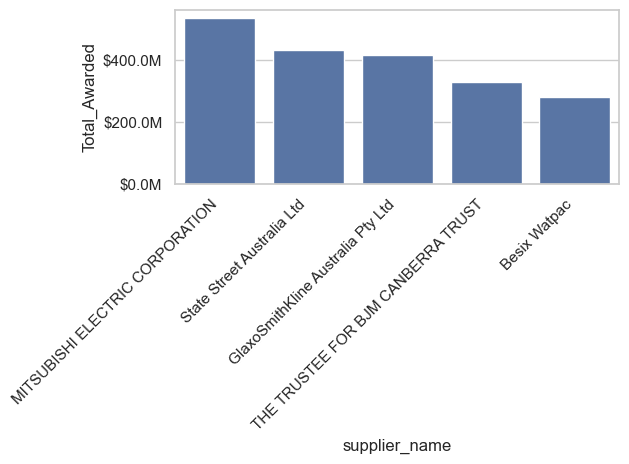

In [12]:
sns.barplot(data=top5_supplier,x='supplier_name',y='Total_Awarded')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_:f'${x/1_000_000:.1f}M')
)
plt.xticks(rotation=45,ha='right')
plt.tight_layout()

In [ ]:
#Contract Description Grouped



#Top 6 Contracts spend grouped by description and total spend







#Top 6 Contract spend grouped by description and ave spend







In [20]:
agency_df = austrade_df.groupby('agency_name').agg({'amount':'sum'})
agency_df

,amount
agency_name,
Administrative Review Tribunal,1.832480e+06
Aged Care Quality and Safety Commission,3.476308e+06
Asbestos and Silica Safety and Eradication Agency,2.400000e+05
Attorney-General's Department,3.605444e+07
Austrade,1.680082e+07
...,...
Safe Work Australia,6.178600e+05
Services Australia,2.952892e+08
Sport Integrity Australia,7.910724e+05


In [21]:
supplier_df = austrade_df.groupby('supplier_name').agg({'amount':'sum'})
supplier_df

,amount
supplier_name,
1 AND ONE PTY LTD,3309691.13
1 London Bridge Street,66780.00
100% TREECYCLE PTY LTD GDE Mulching Services,159775.00
1448 PTY LTD,658326.32
1448 Pty Ltd,2167506.40
...,...
lawyerbank Pty Ltd,173470.00
national Native Title Council Ltd,440000.00
thomsons.com.au,47500.00


In [23]:
category_df = austrade_df.groupby(['contract_description','supplier_name'], as_index=False).agg(
    total = ('amount','sum'),
    average = ('amount','mean'))
category_df

,contract_description,supplier_name,total,average
0,(SOE) Infrastructure Engineer\n,MYNDWORKS Pty Ltd,440440.0,440440.0
1,1 Lead AWS Data Stack Data Engineer,HARSHA CONSULTANTS PTY LTD,349131.2,349131.2
2,"1 x APS6 Clinician, Melbourne, VIC",MARS PARTNERSHIP,243028.5,243028.5
3,12-month overflow for Freedom of Information l...,HALL & WILCOX,250000.0,250000.0
4,200 x Poly Headsets,Enigma Indigenous Peoples Pty Ltd,38582.5,38582.5
...,...,...,...,...
6886,specialist financial transactions data for tou...,CommBank IQ,83930.0,83930.0
6887,2026 Flu Vaccinations,Australian Vaccine Services Pty Ltd,15000.0,15000.0
6888,Business administration services,Russell Stubbs,40000.0,40000.0
6889,Legal Services,Lander & Rogers,11000.0,11000.0


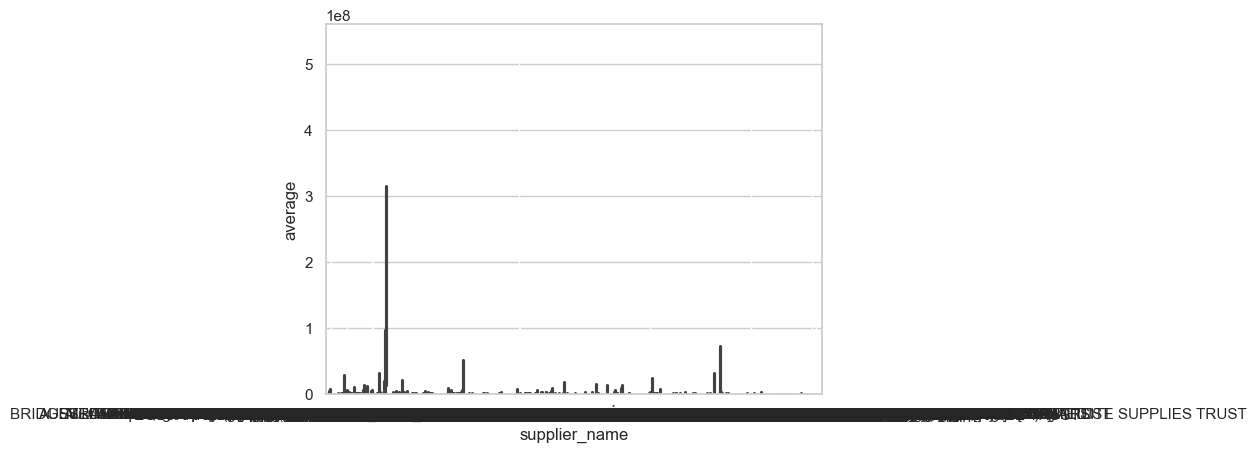

In [24]:
sns.barplot(data=category_df,x='supplier_name',y='average')
plt.show()